## The Galerkin method

### Inner product

The inner product of two functions is defined as

$$(f, g) = \int_\Omega f\, g \; dV .$$


### Operator equation

Differential equations can be written more compactly by introducing an operator equation:

$$A\, u = f, \qquad u \in D(A).$$

Here the operator $A$ contains all the operations applied to the unknown function $u = u(x)$. The order of an operator is the degree of the highest derivative that appears in the operator.

In connection with the order of an operator, the quantity $s$ is introduced with

$$O(A) = 2s .$$

Here $s$ is the number of integrations by parts that can be applied to the operator.


### Boundary conditions

Depending on the operator of the differential equation, two kinds of boundary conditions can be distinguished,
for which the additional quantity $m$ is introduced:

$$O(A) = 2s, \qquad m = s - 1.$$

**Essential or Dirichlet boundary conditions:**
The order of the derivative of the function values prescribed on the boundary (boundary values) is less than or equal to $m$:

$$\frac{d^{(c)} u}{dx^{(c)}} = \text{prescribed on } \partial\Omega \qquad \text{with } c \le m.$$

**Natural or Neumann boundary conditions:**
The order of the derivative of the function values prescribed on the boundary (boundary values) is greater than $m$:

$$\frac{d^{(c)} u}{dx^{(c)}} = \text{prescribed on } \partial\Omega \qquad \text{with } c > m.$$


### Integral form of a differential equation

Consider the general operator equation

$$Au = f.$$

Multiplying both sides by a test function $v$ and integrating the whole expression over the
domain $\Omega$ yields the integral form

$$\int_\Omega Au\; v \; dV = \int_\Omega f\; v \; dV \qquad \text{or} \qquad (Au, v) = (f, v).$$

The test function $v$ is an arbitrary continuously differentiable function that vanishes on the Dirichlet boundary,
i.e. where $u$ is prescribed. On the Neumann boundary $v$ is not subject to any condition.
Every solution of the operator equation is also a solution of the integral form of the operator equation for any
choice of $v$.


### Variational formulation

The variational formulation is obtained from the integral form $(Au, v) = (f, v)$ by integrating by parts $s$ times
and incorporating the boundary conditions. In doing so, $s$ derivatives are moved from $u$ onto the test function $v$.


### Symmetry, positivity and linearity of an operator

An operator is **symmetric** if

$$(Au, v) = (Av, u) \qquad \text{for all } u, v \in D(A).$$

An operator is **positive** if for $u \in D(A)$

$$(Au, u) = 0 \quad \text{for } u = 0, \qquad\qquad (Au, u) > 0 \quad \text{for } u \neq 0.$$

An operator is **linear** if

$$A(u - v) = Au - Av.$$


### Example:

$$-\nabla \cdot \nabla u = f \qquad \text{in } \Omega .$$

- **Operator:** $A = -\nabla \cdot \nabla$, hence $O(A) = 2$, $s = 1$, $m = 0$.
- **Dirichlet boundary condition** ($c = 0 \le m$): $u$ is prescribed on the boundary.
- **Neumann boundary condition** ($c = 1 > m$): the normal derivative $\nabla u \cdot n$ is prescribed on the boundary
  ($n$ is the outward normal vector).
- **Integral form:**
  $$(Au, v) = -\int_\Omega (\nabla \cdot \nabla u)\, v \; dx = \int_\Omega f\, v \; dx = (f, v).$$
- **Integration by parts** (once, since $s = 1$; Gauss's divergence theorem):
  $$-\int_\Omega (\nabla \cdot \nabla u)\, v \; dx = \int_\Omega \nabla u \cdot \nabla v \; dx - \int_{\partial\Omega} (\nabla u \cdot n)\, v \; ds .$$
  The boundary term vanishes where $v = 0$ (Dirichlet boundary) or where $\nabla u \cdot n = 0$ (homogeneous Neumann boundary).
- **Symmetry and positivity:** For $u, v \in D(A)$ with homogeneous boundary conditions the boundary term vanishes, and
  $(Au, v) = \displaystyle\int_\Omega \nabla u \cdot \nabla v \; dx = (Av, u)$ as well as $(Au, u) = \displaystyle\int_\Omega |\nabla u|^2 \; dx \ge 0$.
- **Variational formulation with Neumann boundary $\Gamma$:** On the part $\Gamma \subset \partial\Omega$ let the
  outward heat flux be prescribed, $q \cdot n = g$ with $q = -\nabla u$ (Fourier's law, conductivity 1).
  On the remaining boundary $\partial\Omega \setminus \Gamma$, $u$ is prescribed, and there $v = 0$.
  The variational formulation then reads: Find $u$ such that
  $$\int_\Omega \nabla u \cdot \nabla v \; dx = \int_\Omega f\, v \; dx - \int_\Gamma g\, v \; ds \qquad \text{for all } v .$$

Exactly this form is used in the FEniCS examples below:
the left-hand side as `inner(grad(u), grad(v))*dx` (Sections 1 to 3) and the boundary term `- g*v*ds` (Section 3).


In [1]:
from fenics import *
from matplotlib import pyplot
%matplotlib inline


## Shared setup: mesh, function space, boundary markers

In [2]:
tol = 1e-3
A   = 0.0
B   = 1.0
nr_elements = 20

mesh = IntervalMesh(nr_elements, A, B)
s    = FiniteElement('Lagrange', mesh.ufl_cell(), 1)
V    = FunctionSpace(mesh, s)

def left(x, on_boundary):
    return on_boundary and near(x[0], A, tol)

def right(x, on_boundary):
    return on_boundary and near(x[0], B, tol)


Calling FFC just-in-time (JIT) compiler, this may take some time.


## 1. Dirichlet – Dirichlet

Temperature fixed at both ends: $u(0)=0$, $u(1)=1$, no source term ($f=0$).

Both boundary conditions are essential and are imposed on the function space through
`DirichletBC`. The boundary term of the weak form vanishes because the test function
is zero at both ends, so $a(u,v) = \int u' v' \, dx$ and $L(v) = \int f v \, dx$.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Solving linear variational problem.


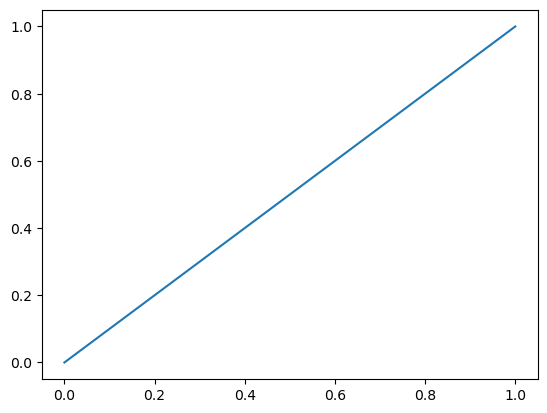

In [3]:
bc0 = DirichletBC(V, Constant(0.0), left)
bc1 = DirichletBC(V, Constant(1.0), right)

u = TrialFunction(V)
v = TestFunction(V)
f = Constant(0.0)

a = inner(grad(u), grad(v)) * dx
L = f * v * dx

u = Function(V)

solve(a == L, u, [bc0, bc1])

pyplot.figure(dpi=100)
plot(u)
pyplot.savefig("temperature-0.png")


## 2. Dirichlet – homogeneous Neumann

Temperature fixed on the left, $u(0)=0$; constant heat source $f=1$.

On the right end the temperature is not prescribed. In the weak form the boundary term
$\int u' v \, ds$ is simply dropped, which corresponds to the **natural**
boundary condition $u'(1)=0$ (insulated end).

Solving linear variational problem.


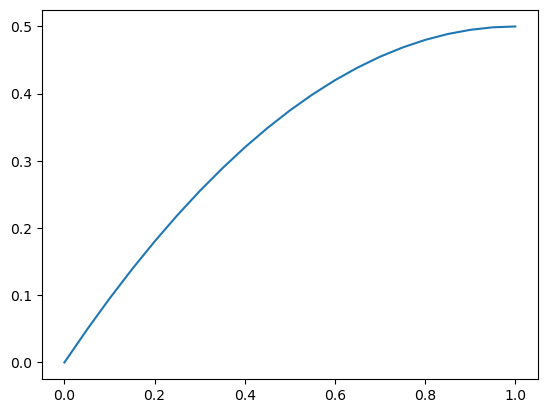

In [4]:
bc = DirichletBC(V, Constant(0.0), left)

u = TrialFunction(V)
v = TestFunction(V)
f = Constant(1.0)

a = inner(grad(u), grad(v)) * dx
L = f * v * dx

u = Function(V)

solve(a == L, u, [bc])

pyplot.figure(dpi=100)
plot(u)
pyplot.savefig("temperature-1.png")


## 3. Dirichlet – Neumann

Temperature fixed on the left, $u(0)=0$; no source ($f=0$).

A prescribed flux $g=-1$ on the right end is imposed through the boundary
integral $\int g\,v\,ds$ in the linear form $L$.

Calling FFC just-in-time (JIT) compiler, this may take some time.


Solving linear variational problem.


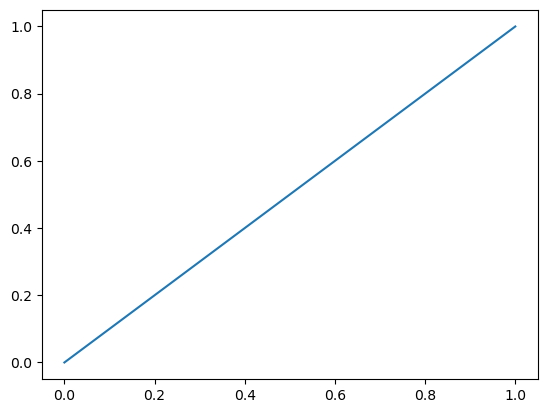

In [5]:
bc = DirichletBC(V, Constant(0.0), left)

u = TrialFunction(V)
v = TestFunction(V)
f = Constant(0.0)
g = Constant(-1.0)

a = inner(grad(u), grad(v)) * dx
L = f * v * dx - g * v * ds

u = Function(V)

solve(a == L, u, [bc])

pyplot.figure(dpi=100)
plot(u)
pyplot.savefig("temperature-2.png")


## Exercises


### Exercise 1: Analytical solution and error norm for Problem 2

Problem 2 reads: $-u'' = 1$ on $(0, 1)$ with $u(0) = 0$ and $u'(1) = 0$.

1. Derive the analytical solution $u(x)$ (integrate twice, insert the boundary conditions).
2. Solve the problem with FEniCS (Lagrange elements of degree 1) and compare the nodal values of the FEM solution
   with $u(x)$ at the nodes. What do you notice? Plot the error $u - u_h$ between the nodes.
3. Define an error norm, e.g. the $L^2$ norm
   $\|u - u_h\|_{L^2} = \big(\int_0^1 (u - u_h)^2 \, dx\big)^{1/2}$,
   and evaluate it with FEniCS (`assemble` or `errornorm`).
4. Increase the polynomial degree of the FEM approximation to 2 and 3 (`FunctionSpace(mesh, 'Lagrange', 2)`)
   and evaluate the error norm again. Explain the result.


### Exercise 2: Biharmonic equation (theory)

Given is the biharmonic equation in 1D on $\Omega = (0, 1)$:

$$A u = \frac{d^4 u}{dx^4} = f .$$

(Beam bending: $u$ is the deflection, $f$ the distributed load.)

1. Determine the order $O(A)$ as well as $s$ and $m$.
2. Set up the integral form $(Au, v) = (f, v)$ and derive the variational formulation by integrating by parts
   $s$ times. Which boundary terms appear?
3. According to the criterion $c \le m$ or $c > m$, which boundary conditions are Dirichlet (essential)
   and which are Neumann (natural) boundary conditions? Which conditions must the test function $v$ satisfy?
4. **Galerkin method with cubic Hermite trial functions: cantilever beam.** We set $f = 0$ and drop the
   boundary terms. The loading is instead prescribed directly as a load vector.

   *Idea:* One chooses finitely many trial functions $h_i(x)$ and seeks the approximation
   $$u_h(x) = \sum_i U_i\, h_i(x)$$
   with unknown coefficients $U_i$. The same functions are used as test functions, $v_h = h_j$.
   Inserting into the variational formulation from item 2 gives, for each $j$,
   $$\sum_i U_i \int_\Omega h_i''\, h_j'' \, dx = \int_\Omega f\, h_j \, dx ,
   \qquad \text{i.e.} \qquad K\, U = F \quad \text{with} \quad K_{ij} = \int_\Omega h_i''\, h_j'' \, dx, \quad F_j = \int_\Omega f\, h_j \, dx .$$

   *Trial functions:* the cubic Hermite interpolation functions on $\Omega = (0, 1)$,
   $$h_1 = 1 - 3x^2 + 2x^3, \qquad h_2 = x - 2x^2 + x^3, \qquad h_3 = 3x^2 - 2x^3, \qquad h_4 = -x^2 + x^3 .$$
   They are constructed such that the coefficients are the boundary values: $U_1 = u_h(0)$, $U_2 = u_h'(0)$, $U_3 = u_h(1)$, $U_4 = u_h'(1)$.
   (Check this using $h_1(0) = 1$ and $h_1'(0) = h_1(1) = h_1'(1) = 0$, and correspondingly for the others.)

   *Task:* The beam is clamped at $x = 0$, $u(0) = 0$ and $u'(0) = 0$, the right end is free.
   Let the load vector for the free degrees of freedom $(U_3, U_4) = (u(1), u'(1))$ be
   $$\underline{F} = \begin{pmatrix} 1 \\ 0 \end{pmatrix},$$
   i.e. a point force $1$ at the free end and no moment.

   a) Which of the $h_j$ are admissible test functions? Which rows and columns of $K$ are therefore needed?

   b) Compute the required entries $K_{33}$, $K_{34}$, $K_{43}$, $K_{44}$. Why is $K_{34} = K_{43}$?

   c) Solve the system of equations and give $u_h(x)$. Compare with the exact solution of $u'''' = 0$ with
      $u(0) = u'(0) = 0$, $u''(1) = 0$ and $u'''(1) = -1$.
